In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
from scipy.stats import pearsonr

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

shrna_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_shRNAone_1nt_260702_3reps.csv"
psp_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_PspCas13b_1nt.csv"
u1_in = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Mastersheet_Input/Log2FC_TTR_RfxCas13d_U1-crRNA_1nt.csv"

shrna_df = pd.read_csv(shrna_in)
psp_df = pd.read_csv(psp_in)
u1_df = pd.read_csv(u1_in)

shrna_df["start_nt_NM_000371.3"] = pd.to_numeric(shrna_df["start_nt_NM_000371.3"], errors="coerce")
psp_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")
u1_df["start_nt_NM_000371.3"] = pd.to_numeric(psp_df["start_nt_NM_000371.3"], errors="coerce")

shrna_df = shrna_df[(shrna_df["start_nt_NM_000371.3"] >= 111) & (shrna_df["start_nt_NM_000371.3"] <= 709)].copy()
psp_df = psp_df[(psp_df["start_nt_NM_000371.3"] >= 111) & (psp_df["start_nt_NM_000371.3"] <= 697)].copy()
u1_df = u1_df[(u1_df["start_nt_NM_000371.3"] >= 111) & (u1_df["start_nt_NM_000371.3"] <= 704)].copy()

output_dir = "/storage/kwonschullab/sumkiu/VERSUS/260626_Versus_Figure5/Figure5_Graph/Reviewed_Figure5/Redo_Figure5"
os.makedirs(output_dir, exist_ok=True)

sigma_nt_default = 2
ttr_offset = 110
xticks_nt = [100, 200, 300, 400, 500, 600]
yticks_main = [-2, 0, 2, 4]
yticks_u1 = [-1, 0, 1, 2]
yticks_psp = [-1, 0, 1, 2, 3]
X_LABEL_TTR = "Guide RNA\nTTR transcript (NM_000371.4)"


In [2]:
def gaussian_smooth_by_nt(x, y, sigma_nt, truncate=4.0):
    x = np.asarray(x)
    y = np.asarray(y)
    if x.ndim != 1 or y.ndim != 1 or x.size != y.size:
        raise ValueError("x and y must be 1D arrays of the same length")
    dx = np.median(np.diff(x))
    if dx <= 0:
        raise ValueError("x must be strictly increasing")
    sigma_idx = sigma_nt / dx
    y_smooth = gaussian_filter1d(y, sigma=sigma_idx, mode="nearest", truncate=truncate)
    return x, y_smooth

In [3]:
# ---------- U1CasRx Day 1 ----------
d_day1 = u1_df[["start_nt_NM_000371.3", "rep3_day1_Log2FC"]].copy()
d_day1["start_nt_NM_000371.3"] = pd.to_numeric(d_day1["start_nt_NM_000371.3"], errors="coerce")
d_day1["rep3_day1_Log2FC"]     = pd.to_numeric(d_day1["rep3_day1_Log2FC"], errors="coerce")
d_day1 = d_day1.dropna(subset=["start_nt_NM_000371.3", "rep3_day1_Log2FC"]).sort_values("start_nt_NM_000371.3")
x_day1 = d_day1["start_nt_NM_000371.3"].to_numpy() - 110
y_day1 = d_day1["rep3_day1_Log2FC"].to_numpy()

# ---------- U1CasRx Day 5 ----------
d_day5 = u1_df[["start_nt_NM_000371.3", "rep3_day5_Log2FC"]].copy()
d_day5["start_nt_NM_000371.3"] = pd.to_numeric(d_day5["start_nt_NM_000371.3"], errors="coerce")
d_day5["rep3_day5_Log2FC"]     = pd.to_numeric(d_day5["rep3_day5_Log2FC"], errors="coerce")
d_day5 = d_day5.dropna(subset=["start_nt_NM_000371.3", "rep3_day5_Log2FC"]).sort_values("start_nt_NM_000371.3")
x_day5 = d_day5["start_nt_NM_000371.3"].to_numpy() - 110
y_day5 = d_day5["rep3_day5_Log2FC"].to_numpy()

# ---------- PSP Cas13b (single timepoint) ----------
d_psp = psp_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()  
d_psp["start_nt_NM_000371.3"] = pd.to_numeric(d_psp["start_nt_NM_000371.3"], errors="coerce")
d_psp["Log2FC_mean"] = pd.to_numeric(d_psp["Log2FC_mean"], errors="coerce")
d_psp = d_psp.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")
x_psp = d_psp["start_nt_NM_000371.3"].to_numpy() - 110
y_psp = d_psp["Log2FC_mean"].to_numpy()

# ---------- shRNA (single timepoint or combined) ----------
# Likewise, adapt the Log2FC column name to your shRNA mastersheet
d_shrna = shrna_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()  # <-- replace "Log2FC" with actual shRNA column
d_shrna["start_nt_NM_000371.3"] = pd.to_numeric(d_shrna["start_nt_NM_000371.3"], errors="coerce")
d_shrna["Log2FC_mean"] = pd.to_numeric(d_shrna["Log2FC_mean"], errors="coerce")
d_shrna = d_shrna.dropna(subset=["start_nt_NM_000371.3", "Log2FC_mean"]).sort_values("start_nt_NM_000371.3")
x_shrna = d_shrna["start_nt_NM_000371.3"].to_numpy() - 110
y_shrna = d_shrna["Log2FC_mean"].to_numpy()

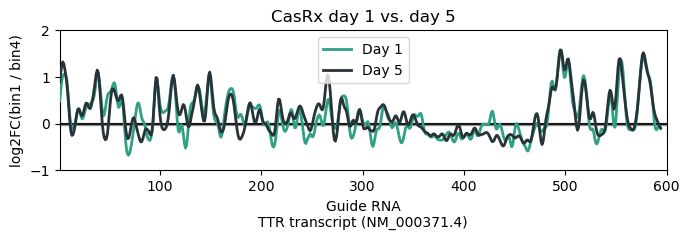

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.5))

if len(x_day1) >= 4:
    xs, ys = gaussian_smooth_by_nt(x_day1, y_day1, sigma_nt_default)
    ax.plot(xs, ys, color="#2FA084", lw=2, zorder=3, label="Day 1")

if len(x_day5) >= 4:
    xs, ys = gaussian_smooth_by_nt(x_day5, y_day5, sigma_nt_default)
    ax.plot(xs, ys, color="#273338", lw=2, zorder=3, label="Day 5")

ax.axhspan(-0.02, 0.02, color="#666666", alpha=0.6, zorder=0)
ax.axhline(0, color="black", lw=1.2, zorder=2)
ax.margins(x=0)
ax.set_ylabel("log2FC(bin1 / bin4)")
ax.set_xticks(xticks_nt)
ax.set_yticks([-1, 0, 1, 2])
ax.set_title("CasRx day 1 vs. day 5")
ax.set_xlabel(X_LABEL_TTR)
ax.legend()

plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "260723Figure5u1day1day5sameplane.pdf"), bbox_inches="tight")
plt.show()

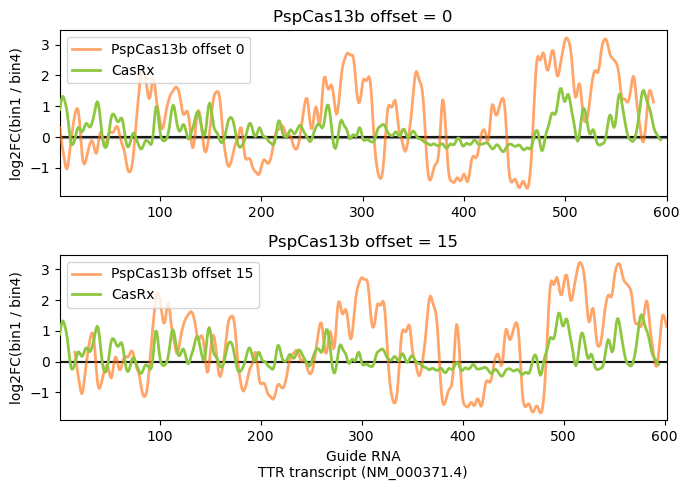

In [6]:
# Offset Set PspCas13b Vs CasRx Gaussian Line 
offsets = [0, 15]
fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharey=True)

line_psp = "#FF7418A4"
line_c_casrx = "#8dc63f"

for ax, offset in zip(axes, offsets):
    # PspCas13b (with offset)
    d_psp = psp_df[["start_nt_NM_000371.3", "Log2FC_mean"]].copy()
    d_psp["Log2FC_mean"] = pd.to_numeric(d_psp["Log2FC_mean"], errors="coerce")
    d_psp = d_psp.dropna().sort_values("start_nt_NM_000371.3")
    x_psp = d_psp["start_nt_NM_000371.3"].to_numpy() - 110 + offset
    y_psp = d_psp["Log2FC_mean"].to_numpy()

    # CasRx day5 (no offset)
    d_u1 = u1_df[["start_nt_NM_000371.3", "rep3_day5_Log2FC"]].copy()
    d_u1["start_nt_NM_000371.3"] = pd.to_numeric(d_u1["start_nt_NM_000371.3"], errors="coerce")
    d_u1 = d_u1.dropna().sort_values("start_nt_NM_000371.3")
    x_u1 = d_u1["start_nt_NM_000371.3"].to_numpy() - 110
    y_u1 = d_u1["rep3_day5_Log2FC"].to_numpy()

    # smoothed lines using shared Gaussian helper
    if len(x_psp) >= 4:
        x_psp_s, y_psp_s = gaussian_smooth_by_nt(x_psp, y_psp, sigma_nt_default)
        ax.plot(x_psp_s, y_psp_s, color=line_psp, linewidth=2,
                zorder=3, label=f"PspCas13b offset {offset}")

    if len(x_u1) >= 4:
        x_u1_s, y_u1_s = gaussian_smooth_by_nt(x_u1, y_u1, sigma_nt_default)
        ax.plot(x_u1_s, y_u1_s, color=line_c_casrx, linewidth=2,
                zorder=3, label="CasRx")

    # styling
    ax.axhspan(-0.02, 0.02, color="#666666", alpha=0.6, zorder=0)
    ax.axhline(0, color="black", linewidth=1.2, zorder=2)
    ax.margins(x=0)
    ax.set_xticks([100, 200, 300, 400, 500, 600])
    ax.set_yticks([-1, 0, 1, 2, 3])
    ax.set_ylabel("log2FC(bin1 / bin4)")
    ax.set_title(f"PspCas13b offset = {offset}")
    ax.legend()

axes[-1].set_xlabel("Guide RNA\nTTR transcript (NM_000371.4)")

plt.tight_layout()
# plt.savefig(os.path.join(output_dir,"260723_Figure5_Psp_CasRx_0_15.pdf"),format="pdf",bbox_inches="tight")
plt.show()

d_u1 columns: ['start_nt_NM_000371.3', 'rep3_day5_Log2FC']
merged columns: ['start_nt_NM_000371.3', 'rep3_day5_Log2FC', 'Log2FC_mean']
u1_col_name: rep3_day5_Log2FC present? True
psp_col_name: Log2FC_mean present? True
Best offset: 15 with Pearson r: 0.3053258396303609


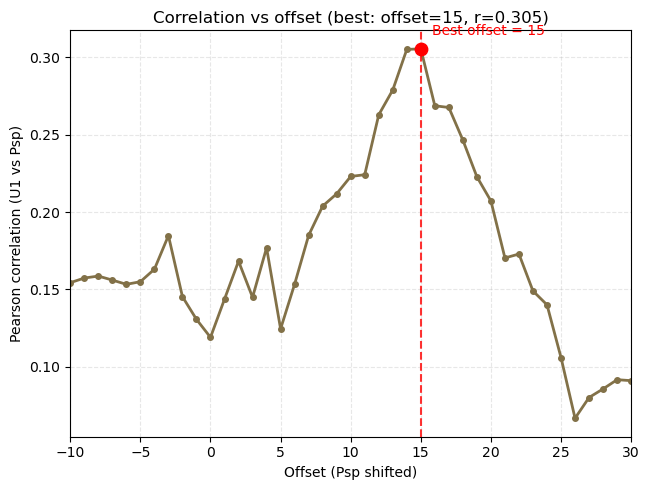

In [8]:
# Offset Set PspCas13b Vs CasRx Trend 

offset_range = list(range(-10, 31))

results = []
best_corr = -float("inf")
best_offset = None

u1_col_name = "rep3_day5_Log2FC"
psp_col_name = "Log2FC_mean"

for offset in offset_range:
    d_psp_tmp = d_psp.copy()
    d_psp_tmp["start_nt_NM_000371.3"] = d_psp_tmp["start_nt_NM_000371.3"] + offset

    shared = pd.merge(
        d_u1, d_psp_tmp,
        on="start_nt_NM_000371.3",
        suffixes=["_U1", "_Psp"]
    )

    # Optional debug on first offset
    if offset == 0:
        print("d_u1 columns:", d_u1.columns.tolist())
        print("merged columns:", shared.columns.tolist())
        print("u1_col_name:", u1_col_name, "present?", u1_col_name in shared.columns)
        print("psp_col_name:", psp_col_name, "present?", psp_col_name in shared.columns)

    if shared.empty or shared[u1_col_name].nunique() < 2 or shared[psp_col_name].nunique() < 2:
        corr = float("nan")
    else:
        corr = shared[u1_col_name].corr(shared[psp_col_name], method="pearson")

    if corr > best_corr and not pd.isna(corr):
        best_corr = corr
        best_offset = offset

    results.append({
        "offset": offset,
        "pearson_correlation": corr,
        "n_shared_positions": len(shared)
    })


results_df = pd.DataFrame(results)

# Save correlation table
# csv_path = os.path.join(output_dir, "260706_datapoint_offset_correlation_psp_U1.csv")
# results_df.to_csv(csv_path, index=False)

print("Best offset:", best_offset, "with Pearson r:", best_corr)

# Plot correlation vs offset
fig, ax = plt.subplots(figsize=(6.6, 5))

offsets = results_df["offset"]
corrs = results_df["pearson_correlation"]

ax.plot(offsets, corrs, color="#827148", linewidth=2, marker="o", markersize=4)

if best_offset is not None:
    best_row = results_df[results_df["offset"] == best_offset].iloc[0]

    ax.scatter(
        [best_row["offset"]],
        [best_row["pearson_correlation"]],
        color="red",
        s=80,
        zorder=5
    )

    ax.axvline(
        best_offset,
        color="red",
        linestyle="--",
        linewidth=1.5,
        alpha=0.8,
        zorder=3
    )

    ax.annotate(
        f"Best offset = {best_offset}",
        xy=(best_row["offset"], best_row["pearson_correlation"]),
        xytext=(8, 8),
        textcoords="offset points",
        color="red",
        fontsize=10,
        ha="left",
        va="bottom"
    )

ax.set_xlabel("Offset (Psp shifted)")
ax.set_ylabel("Pearson correlation (U1 vs Psp)")
ax.set_title(f"Correlation vs offset (best: offset={best_offset}, r={best_corr:.3f})")
ax.grid(True, linestyle="--", alpha=0.3)
ax.margins(x=0)

plt.tight_layout()
# pdf_path = os.path.join(output_dir, "260710_datapoint_offset_correlation_psp_U1.pdf")
# plt.savefig(pdf_path, format="pdf", bbox_inches="tight")
plt.show()

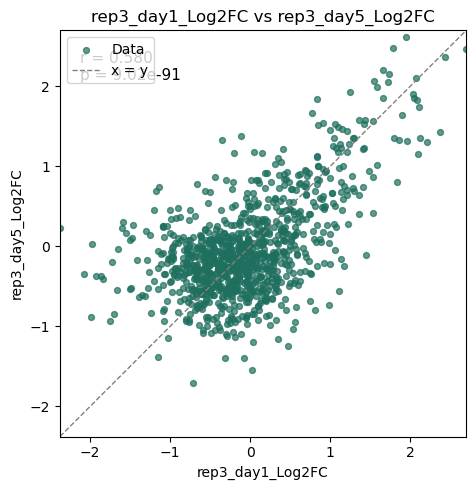

In [7]:
# Correlation of U1Rx Day 1 and Day 5
u1_df = pd.read_csv(u1_in)

rep_cols = ["rep3_day1_Log2FC", "rep3_day5_Log2FC"]
corr_df = u1_df[rep_cols].apply(pd.to_numeric, errors="coerce").dropna()

pairs = [
    ("rep3_day1_Log2FC", "rep3_day5_Log2FC"),
]

# Square figure: width == height
fig, axes = plt.subplots(1, len(pairs), figsize=(5, 5), sharey=True)

# If only one pair, axes will be a single Axes object; make it iterable
if len(pairs) == 1:
    axes = [axes]

for ax, (xcol, ycol) in zip(axes, pairs):
    x = corr_df[xcol]
    y = corr_df[ycol]
    r, p = pearsonr(x, y)

    # Determine limits for x=y line and axes (symmetric)
    min_val = min(x.min(), y.min())
    max_val = max(x.max(), y.max())

    # Scatter
    ax.scatter(x, y, s=18, alpha=0.7, color="#1F6F5F", label="Data")

    # x = y reference line (dotted)
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        color="gray",
        linewidth=1.0,
        label="x = y"
    )

    # Square axes with equal scaling
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_title(f"{xcol} vs {ycol}")

    # Pearson r and p in textbox
    ax.text(
        0.05, 0.95,
        f"r = {r:.3f}\np = {p:.2e}",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Legend
    ax.legend(loc="upper left")

plt.tight_layout()
# plt.savefig(os.path.join(output_dir, "260717_Figure5_u1Rx_rep3_day1_5_correlation_scatter.pdf"), format="pdf", bbox_inches="tight")
plt.show()